In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [108]:
dataset = pd.read_csv('train.csv')
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [109]:
dataset.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [110]:
dataset = dataset.drop(['Cabin','Name','PassengerId','Ticket'], axis=1)

In [111]:
dataset['Age'] = dataset['Age'].fillna(dataset['Age'].mean())
dataset['Fare'] = dataset['Fare'].fillna(dataset['Fare'].mean())
dataset['Embarked'] = dataset['Embarked'].fillna(dataset['Embarked'].mode()[0])
dataset.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [112]:
dataset.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [113]:
dataset['Sex'] = dataset['Sex'].map({"male":0,"female":1})
dataset['Embarked'] = dataset['Embarked'].map({"S":0,"C":1,"Q":2})

In [114]:
dataset.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
395,0,3,0,22.000000,0,0,7.7958,0
851,0,3,0,74.000000,0,0,7.7750,0
392,0,3,0,28.000000,2,0,7.9250,0
420,0,3,0,29.699118,0,0,7.8958,1
538,0,3,0,29.699118,0,0,14.5000,0


In [115]:
X = dataset[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']]
Y = dataset['Survived']

In [116]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=25)

In [117]:
model = LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [118]:
predictions = model.predict(x_test)
prediction = model.predict(x_train)

In [119]:
T_accuracy = accuracy_score(y_train, prediction)

print("Accuracy on Train data:", T_accuracy)

Accuracy on Train data: 0.7907303370786517


In [120]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy on Test data:", accuracy)

Accuracy on Test data: 0.7877094972067039


#Testing on Test data


In [121]:
test = pd.read_csv('test.csv')
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [122]:
test = test.drop(['Cabin','Name','PassengerId','Ticket'], axis=1)
test.sample(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
102,3,male,NaN,0,0,7.7500,Q
19,3,female,45.0,0,0,7.2250,C
15,2,female,24.0,1,0,27.7208,C
158,1,male,42.0,0,0,26.5500,S
31,2,male,24.0,2,0,31.5000,S


In [123]:
test.isnull().sum()

,0
Pclass,0
Sex,0
Age,86
SibSp,0
Parch,0
Fare,1
Embarked,0


In [124]:
test['Age'] = test['Age'].fillna(test['Age'].mean())
test['Fare'] = test['Fare'].fillna(test['Fare'].mean())
test.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [125]:
test['Sex'] = test['Sex'].map({"male":0,"female":1})
test['Embarked'] = test['Embarked'].map({"S":0,"C":1,"Q":2})

In [105]:
testing = test[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']]

In [106]:
test_predictions = model.predict(testing)
print(test_predictions)

[0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1 0 0 0 0 0 0 1 1 0 1
 1 0 0 0 0 0 1 1 0 0 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 1 1 1 0 1 1
 1 1 0 1 0 1 0 0 0 0 0 0 1 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0
 1 1 1 1 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 1 1 0 1 1 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1
 0 1 0 1 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1 1 0 1 0 0 0 0 1 0 0 1 0 1 0 1 0
 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 1
 0 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 1 0 0 1 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 1 1 0 1 1 0
 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0
 0 1 1 1 1 1 0 1 0 0 0]


##Visualise

<Axes: xlabel='Survived', ylabel='count'>

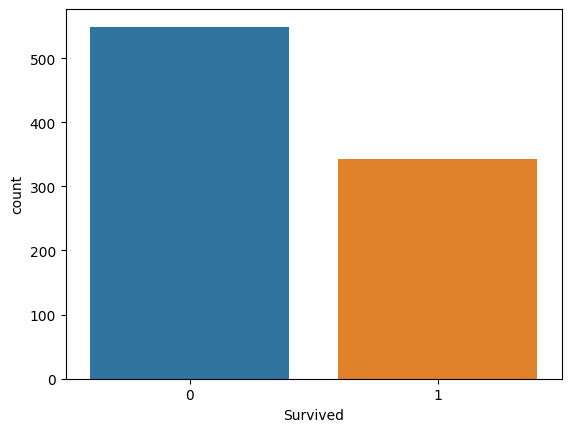

In [130]:
sns.countplot(x='Survived',hue='Survived', data=dataset, legend=False)

<Axes: xlabel='Sex', ylabel='count'>

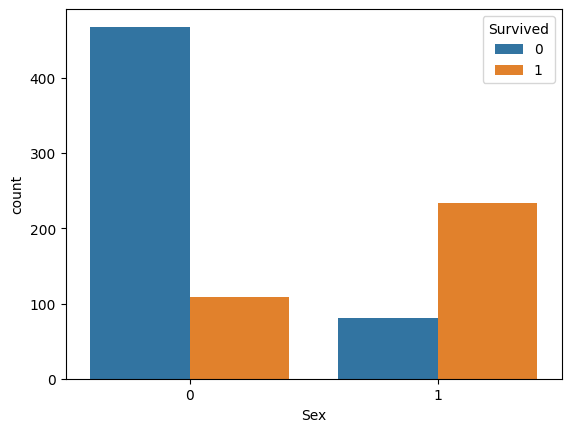

In [131]:
sns.countplot(x='Sex',hue='Survived', data=dataset)

#**Implementation**

In [133]:
print("\nEnter Passenger Details")

pclass = int(input("Passenger Class (1/2/3): "))
sex = input("Sex (male/female): ").lower()
age = float(input("Age: "))
fare = float(input("Fare: "))
embarked = input("Embarked (S/C/Q): ").upper()

# Convert categorical data

if sex == 'male':
    sex = 0
else:
    sex = 1

if embarked == 'S':
    embarked = 0
elif embarked == 'C':
    embarked = 1
else:
    embarked = 2

sample = [[pclass, sex, age, fare, embarked]]

# Predict

prediction = model.predict(sample)

# Output

if prediction[0] == 1:
    print("\nPassenger would SURVIVE")
else:
    print("\nPassenger would NOT SURVIVE")


Enter Passenger Details
Passenger Class (1/2/3): 1
Sex (male/female): female
Age: 19
Fare: 10999
Embarked (S/C/Q): Q

Passenger would SURVIVE


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
